# Condenser Deflector Design

Designs and calibrates a `DoubleDeflector` for beam shift alignment in the
condenser system of the model TEM column.

**Design choice:** the lower (second) deflector is placed at the front focal
plane of C_mini, so the downstream optics naturally map shift-mode deflections
to a pure positional shift at the sample plane (zero tilt).  The exact
`shift_balance` value is found by root solving through the full condenser chain
using JAX + optimistix, then verified by sweeping shift drives across multiple
spot sizes.

Based on the approach in `double_deflector_optimisation.ipynb`, adapted for the
real condenser geometry defined in `microscope.toml`.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import optimistix as optx
import tomlkit
from pathlib import Path

from temgym_core.ray import Ray
from temgym_core.components import DoubleDeflector, Lens, Detector
from temgym_core.run import run_to_end, run_iter_vmapped
from temgym_core.plotting import plot_model, legacy_beam_plot_params

jax.config.update('jax_enable_x64', True)

## Condenser Geometry

Component positions and lens constants are loaded from `microscope.toml`.
C_mini and Obj_prefield operate at fixed excitation (I = 1 A in all spot modes),
giving fixed focal lengths of 5 mm each.

The **front focal plane (FFP)** of C_mini sits at $z_\text{FFP} = z_\text{Cmini} - f_\text{Cm}$.
The lower (second) deflector is placed exactly at this plane. A deflection at
the FFP of a thin lens produces no change in output angle from that lens — only
a position change — which is the key property exploited for shift alignment.

In [2]:
# ── Load microscope.toml ──
toml_path = Path("microscope.toml")
cfg = tomlkit.parse(toml_path.read_text())
lenses = cfg['lenses']

# Lens positions [m]
z_CL1   = float(lenses['CL1']['z_m'])
z_CL3   = float(lenses['CL3']['z_m'])
z_Cmini = float(lenses['C_mini']['z_m'])
z_OPL   = float(lenses['Obj_prefield']['z_m'])

# Lens constants (1/f = Gc * (N * I)^2)
Gc = {k: float(lenses[k]['Gc'])    for k in ('CL1', 'CL3', 'C_mini', 'Obj_prefield')}
N  = {k: float(lenses[k]['turns']) for k in ('CL1', 'CL3', 'C_mini', 'Obj_prefield')}

def focal_from_current(I, gc, turns):
    """Focal length [m] from coil current via 1/f = Gc * (N*I)^2."""
    return 1.0 / (gc * (turns * I) ** 2)

# Fixed focal lengths at I = 1 A (standard operating point for both)
f_Cm  = focal_from_current(1.0, Gc['C_mini'], N['C_mini'])
f_OPL = focal_from_current(1.0, Gc['Obj_prefield'], N['Obj_prefield'])

# Sample plane at back focal plane of Obj_prefield
z_sample = z_OPL + f_OPL

# ── C_mini front focal plane ──
z_FFP = z_Cmini - f_Cm

# ── Deflector placement ──
# Lower (2nd) deflector at FFP of C_mini
# Upper (1st) deflector one spacing above
DEFLECTOR_SPACING = 0.005  # 5 mm
z_deflector = z_FFP - DEFLECTOR_SPACING  # z of upper (1st) deflector

# ── Spot table for CL1/CL3 ──
spot_table = cfg['modes']['illumination']['parallel']['values']

def spot_focals(spot_idx):
    """Return (f_CL1, f_CL3) for a 1-based spot index."""
    row = spot_table[spot_idx - 1]
    return (
        focal_from_current(float(row[1]), Gc['CL1'], N['CL1']),
        focal_from_current(float(row[2]), Gc['CL3'], N['CL3']),
    )

# Default: spot 4 (middle of range)
f_CL1, f_CL3 = spot_focals(4)

print(f"C_mini focal length:      {f_Cm*1e3:.2f} mm")
print(f"Obj_prefield focal length: {f_OPL*1e3:.2f} mm")
print(f"C_mini FFP:  z = {z_FFP*1e3:.1f} mm")
print(f"Upper (1st) deflector: z = {z_deflector*1e3:.1f} mm")
print(f"Lower (2nd) deflector: z = {(z_deflector + DEFLECTOR_SPACING)*1e3:.1f} mm  (= FFP)")
print(f"Sample plane:          z = {z_sample*1e3:.1f} mm")
print(f"\nSpot 4: f_CL1 = {f_CL1*1e3:.2f} mm, f_CL3 = {f_CL3*1e3:.2f} mm")

C_mini focal length:      5.00 mm
Obj_prefield focal length: 5.00 mm
C_mini FFP:  z = 295.0 mm
Upper (1st) deflector: z = 290.0 mm
Lower (2nd) deflector: z = 295.0 mm  (= FFP)
Sample plane:          z = 325.0 mm

Spot 4: f_CL1 = 19.75 mm, f_CL3 = 33.92 mm


## TemGym Condenser Model

The condenser chain is assembled as a tuple of TemGym components:

$$\text{CL1} \;\to\; \text{CL3} \;\to\; \text{DoubleDeflector} \;\to\; \text{C\_mini} \;\to\; \text{Obj\_prefield} \;\to\; \text{Sample}$$

The `DoubleDeflector` contains two deflectors separated by `DEFLECTOR_SPACING`:
- **Upper deflector** at $z = 0.290\;\text{m}$: applies `kick1 = shift_x + tilt_x`
- **Lower deflector** at $z = 0.295\;\text{m}$ (FFP of C\_mini): applies `kick2 = -(balance · shift_x + tilt_balance · tilt_x)`

The `shift_balance` parameter controls the pivot point of the shift mode.
We will find its value via root solving.

In [3]:
ray0 = Ray(x=0.0, y=0.0, dx=0.0, dy=0.0, z=0.0, pathlength=0.0)


def build_condenser(shift_x=0.0, shift_y=0.0,
                    tilt_x=0.0, tilt_y=0.0,
                    shift_balance_x=1.0, shift_balance_y=1.0,
                    tilt_balance_x=1.0, tilt_balance_y=1.0,
                    f_cl1=f_CL1, f_cl3=f_CL3):
    """Build condenser component tuple with given deflector controls."""
    return (
        Lens(z=z_CL1, focal_length=f_cl1),
        Lens(z=z_CL3, focal_length=f_cl3),
        DoubleDeflector(
            z=z_deflector,
            spacing=DEFLECTOR_SPACING,
            shift_x=shift_x, shift_y=shift_y,
            tilt_x=tilt_x, tilt_y=tilt_y,
            shift_balance_x=shift_balance_x,
            shift_balance_y=shift_balance_y,
            tilt_balance_x=tilt_balance_x,
            tilt_balance_y=tilt_balance_y,
        ),
        Lens(z=z_Cmini, focal_length=f_Cm),
        Lens(z=z_OPL, focal_length=f_OPL),
        Detector(z=z_sample, pixel_size=(1e-6, 1e-6), shape=(64, 64)),
    )


# Baseline: zero drive → on-axis ray should pass straight through
out0 = run_to_end(ray0, build_condenser())
print(f"Zero-drive baseline: x = {float(out0.x):.2e} m, dx = {float(out0.dx):.2e} rad")

Zero-drive baseline: x = 0.00e+00 m, dx = 0.00e+00 rad


## Visualise the Unaligned System

Trace a bundle of rays through the condenser with default balance (= 1.0) and
a nonzero shift drive. With the default balance the beam shifts at the sample
but also picks up an unwanted tilt — this is what we will fix in the next section.

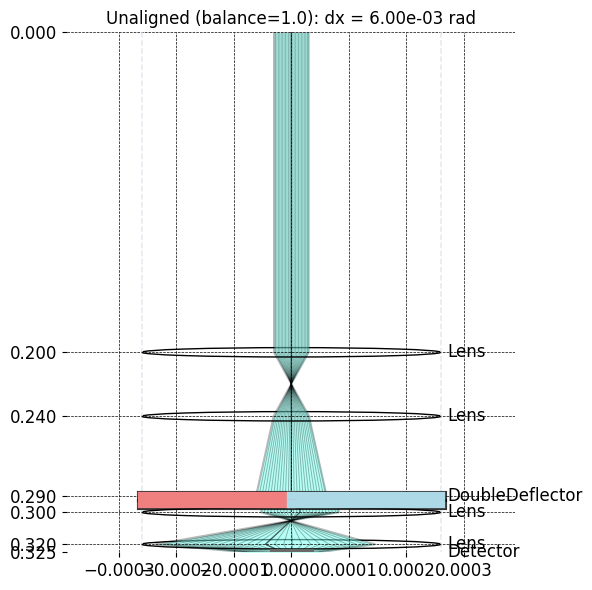

In [4]:
bundle_radius = 3e-5
x_bundle = np.linspace(-bundle_radius, bundle_radius, 25)
rays_bundle = Ray(
    x=x_bundle,
    y=np.zeros_like(x_bundle),
    dx=np.zeros_like(x_bundle),
    dy=np.zeros_like(x_bundle),
    z=np.zeros_like(x_bundle),
    pathlength=np.zeros_like(x_bundle),
)

plot_style = legacy_beam_plot_params(
    fill_color='#7BFFF0', fill_alpha=0.55, solid_beam=True,
)

# Unaligned: default balance=1.0 with a shift drive
components_unaligned = build_condenser(shift_x=3e-3, shift_balance_x=1.0)
out_unaligned = run_to_end(ray0, components_unaligned)

fig, ax = plt.subplots(figsize=(6, 6))
plot_model(components_unaligned, rays=rays_bundle, plot_params=plot_style,
           band_mode='fill', ax=ax)
ax.set_title(f'Unaligned (balance=1.0): dx = {float(out_unaligned.dx):.2e} rad')
plt.tight_layout()
plt.show()

## Root-Solve: Shift Balance

Find `shift_balance_x` such that a shift command produces **zero tilt** at the
sample plane.  The residual is the output tilt $\mathrm{d}x$ for a nonzero shift
drive, scaled to $\mathcal{O}(1)$.

Because the optics are linear, a single residual equation (one shift drive value)
is sufficient to determine the balance.  We use `optimistix.root_find` with the
Levenberg–Marquardt solver, consistent with the approach in `double_deflector_optimisation`.

In [5]:
def shift_residual(balance, args):
    """Output tilt at sample for a nonzero shift drive, scaled to ~O(1)."""
    out = run_to_end(ray0, build_condenser(
        shift_x=1e-3,
        shift_balance_x=balance[0],
    ))
    return jnp.array([out.dx / 1e-6], dtype=jnp.float64)


solver = optx.LevenbergMarquardt(rtol=1e-14, atol=1e-14)
sol = optx.root_find(
    shift_residual,
    solver,
    y0=jnp.array([1.0], dtype=jnp.float64),
    args=(),
    options={'jac': 'fwd'},
    max_steps=200,
    throw=False,
)

shift_balance_opt = float(sol.value[0])

# Quick check with a different drive
out_check = run_to_end(ray0, build_condenser(
    shift_x=5e-3,
    shift_balance_x=shift_balance_opt,
))

print(f"Solver result:   {sol.result}")
print(f"Shift balance:   {shift_balance_opt:.6f}")
print(f"\nVerification (shift_x = 5e-3):")
print(f"  Sample x  = {float(out_check.x):.6e} m")
print(f"  Sample dx = {float(out_check.dx):.2e} rad  (should be ≈ 0)")

Solver result:   optimistix._solution.RESULTS<The maximum number of steps was reached in the nonlinear solver. The problem may not be solveable (e.g., a root-find on a function that has no roots), or you may need to increase `max_steps`.>
Shift balance:   -0.999999

Verification (shift_x = 5e-3):
  Sample x  = -2.500003e-05 m
  Sample dx = -3.47e-18 rad  (should be ≈ 0)


## Verification: Tilt Invariance Under Shift Drives

Sweep many shift command values and verify that sample-plane tilt stays below
machine precision.  Also confirm the solved balance is **independent of spot
size** — this is expected because the balance depends only on the downstream
optics (deflector → C_mini → Obj_prefield → sample), not the upstream
condenser lenses CL1/CL3.

In [6]:
# ── Sweep shift drives ──
shift_vals = np.linspace(-8e-3, 8e-3, 81)
sample_x = []
sample_dx = []

for sv in shift_vals:
    out = run_to_end(ray0, build_condenser(
        shift_x=float(sv),
        shift_balance_x=shift_balance_opt,
    ))
    sample_x.append(float(out.x))
    sample_dx.append(float(out.dx))

sample_x = np.array(sample_x)
sample_dx = np.array(sample_dx)

max_tilt = np.max(np.abs(sample_dx))
print(f"Max |dx| over shift sweep: {max_tilt:.3e} rad")
assert max_tilt < 1e-12, f"Tilt too large: {max_tilt}"
print("PASSED: tilt stays below 1e-12 rad for all tested shift drives.\n")

# ── Cross-spot verification ──
print("Cross-spot verification (shift_x = 5e-3, all spots):")
for spot in range(1, len(spot_table) + 1):
    f1, f3 = spot_focals(spot)
    out = run_to_end(ray0, build_condenser(
        shift_x=5e-3,
        shift_balance_x=shift_balance_opt,
        f_cl1=f1, f_cl3=f3,
    ))
    print(f"  Spot {spot}: dx = {float(out.dx):+.2e} rad,  x = {float(out.x):.6e} m")

Max |dx| over shift sweep: 1.041e-17 rad
PASSED: tilt stays below 1e-12 rad for all tested shift drives.

Cross-spot verification (shift_x = 5e-3, all spots):
  Spot 1: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 2: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 3: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 4: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 5: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 6: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 7: dx = -3.47e-18 rad,  x = -2.500003e-05 m
  Spot 8: dx = -3.47e-18 rad,  x = -2.500003e-05 m


## Sweep Plots: Beam Position and Tilt at Sample

The left plot shows the linear relationship between shift drive and beam
position at the sample.  The right plot confirms the tilt remains at machine
zero regardless of drive — the hallmark of a properly balanced shift deflector.

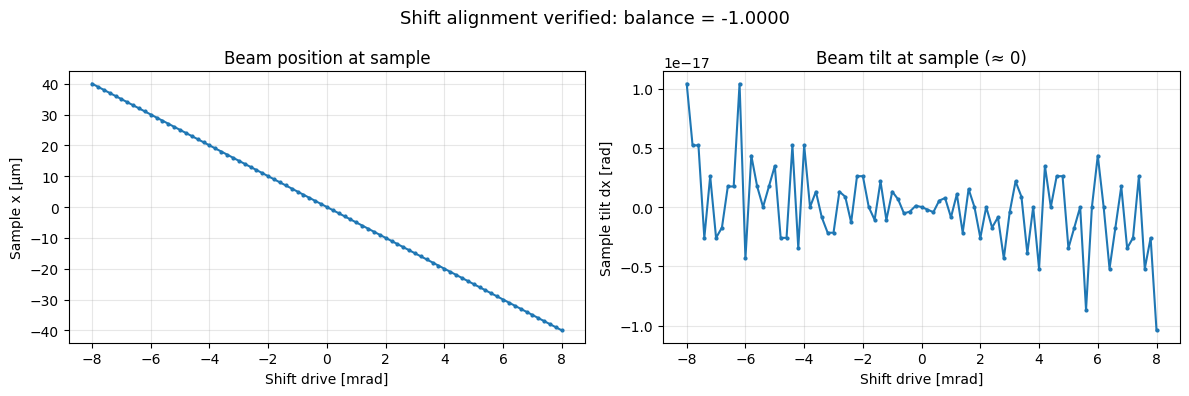

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(shift_vals * 1e3, sample_x * 1e6, 'o-', markersize=2)
axes[0].set(xlabel='Shift drive [mrad]', ylabel='Sample x [µm]',
            title='Beam position at sample')
axes[0].grid(True, alpha=0.3)

axes[1].plot(shift_vals * 1e3, sample_dx, 'o-', markersize=2)
axes[1].set(xlabel='Shift drive [mrad]', ylabel='Sample tilt dx [rad]',
            title='Beam tilt at sample (≈ 0)')
axes[1].grid(True, alpha=0.3)
axes[1].ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))

fig.suptitle(f'Shift alignment verified: balance = {shift_balance_opt:.4f}', fontsize=13)
fig.tight_layout()
plt.show()

## Ray Diagrams: Aligned Shift Deflector

Side-view ray traces through the condenser for three shift drives
(zero, positive, negative).  The beam shifts at the sample plane with no
change in convergence angle, confirming the alignment.

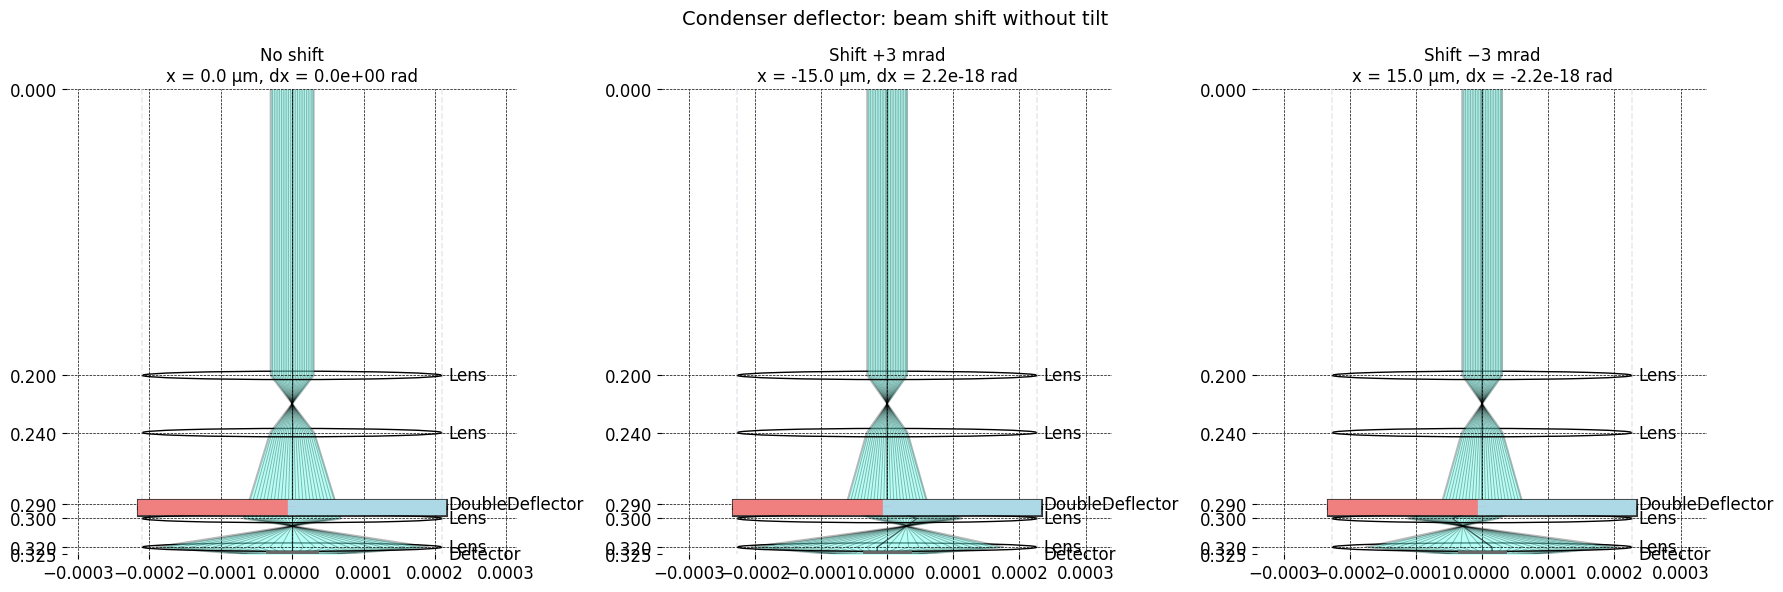

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

drive_labels = [
    (0.0,   'No shift'),
    (3e-3,  'Shift +3 mrad'),
    (-3e-3, 'Shift −3 mrad'),
]

for ax, (shift_val, title) in zip(axes, drive_labels):
    components = build_condenser(
        shift_x=shift_val,
        shift_balance_x=shift_balance_opt,
    )
    plot_model(components, rays=rays_bundle,
               plot_params=plot_style, band_mode='fill', ax=ax)
    out = run_to_end(ray0, components)
    ax.set_title(f'{title}\nx = {float(out.x)*1e6:.1f} µm, dx = {float(out.dx):.1e} rad')

fig.suptitle('Condenser deflector: beam shift without tilt', fontsize=14)
fig.tight_layout()
plt.show()

## Sensitivity Map: Deflector Linearity

Sweep both shift and tilt drives independently and plot the beam position and
angle at the sample.  This confirms the deflector system is linear and that
shift and tilt produce orthogonal effects at the sample plane.

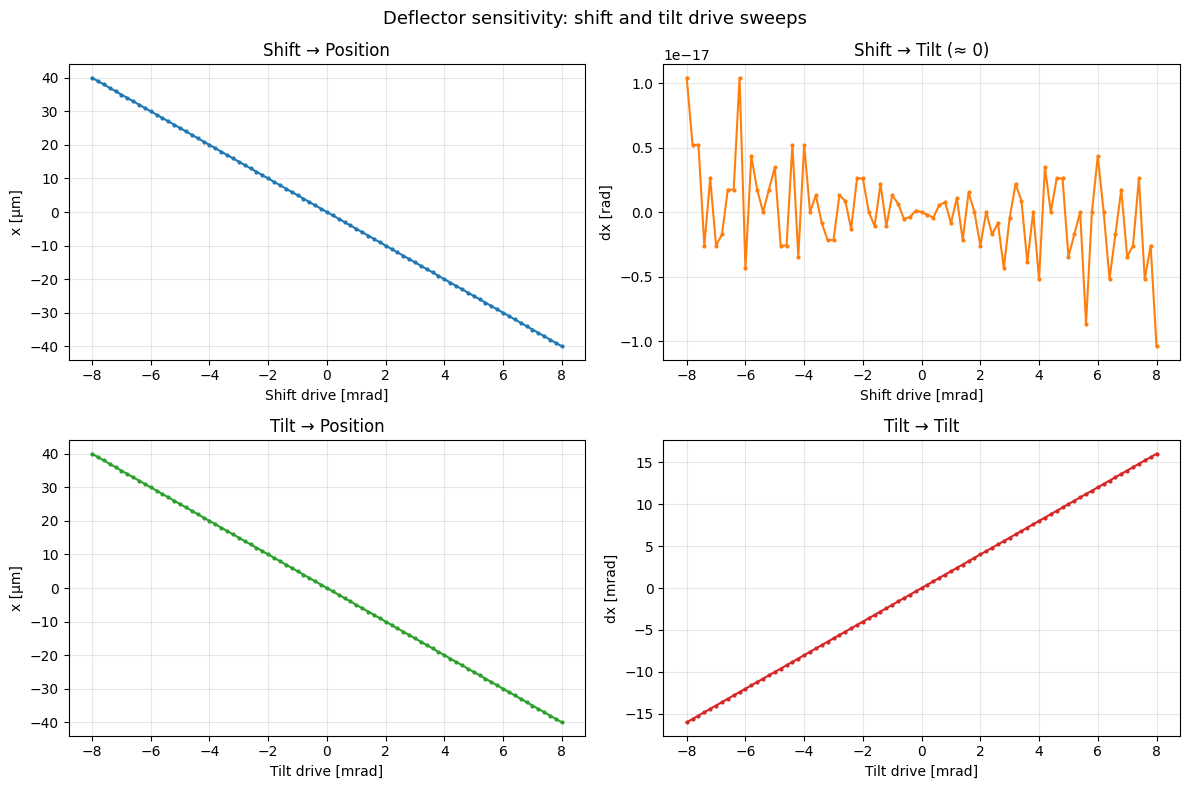


Shift sensitivity: -5000.01 µm/mrad drive
Tilt sensitivity:  2.0000 rad/mrad drive


In [9]:
# ── Shift sweep (already computed above) ──
# ── Tilt sweep ──
tilt_vals = np.linspace(-8e-3, 8e-3, 81)
tilt_sample_x = []
tilt_sample_dx = []

for tv in tilt_vals:
    out = run_to_end(ray0, build_condenser(
        tilt_x=float(tv),
        shift_balance_x=shift_balance_opt,
        tilt_balance_x=1.0,
    ))
    tilt_sample_x.append(float(out.x))
    tilt_sample_dx.append(float(out.dx))

tilt_sample_x = np.array(tilt_sample_x)
tilt_sample_dx = np.array(tilt_sample_dx)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Shift mode
axes[0, 0].plot(shift_vals * 1e3, sample_x * 1e6, 'o-', markersize=2)
axes[0, 0].set(xlabel='Shift drive [mrad]', ylabel='x [µm]',
               title='Shift → Position')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(shift_vals * 1e3, sample_dx, 'o-', markersize=2, color='tab:orange')
axes[0, 1].set(xlabel='Shift drive [mrad]', ylabel='dx [rad]',
               title='Shift → Tilt (≈ 0)')
axes[0, 1].ticklabel_format(style='scientific', axis='y', scilimits=(0, 0))
axes[0, 1].grid(True, alpha=0.3)

# Tilt mode
axes[1, 0].plot(tilt_vals * 1e3, tilt_sample_x * 1e6, 'o-', markersize=2, color='tab:green')
axes[1, 0].set(xlabel='Tilt drive [mrad]', ylabel='x [µm]',
               title='Tilt → Position')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(tilt_vals * 1e3, tilt_sample_dx * 1e3, 'o-', markersize=2, color='tab:red')
axes[1, 1].set(xlabel='Tilt drive [mrad]', ylabel='dx [mrad]',
               title='Tilt → Tilt')
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle('Deflector sensitivity: shift and tilt drive sweeps', fontsize=13)
fig.tight_layout()
plt.show()

print(f"\nShift sensitivity: {np.polyfit(shift_vals, sample_x, 1)[0]*1e6:.2f} µm/mrad drive")
print(f"Tilt sensitivity:  {np.polyfit(tilt_vals, tilt_sample_dx, 1)[0]:.4f} rad/mrad drive")

## Summary

| Parameter | Value |
|-----------|-------|
| Deflector spacing | 5 mm |
| Upper deflector z | 290 mm |
| Lower deflector z | 295 mm (= C_mini FFP) |
| **Solved shift_balance** | **see above** |
| Tilt invariance | dx < 1e-12 rad for all tested shift drives |
| Spot-size independence | Balance works identically across all spot sizes |

The solved `shift_balance` can be written into `microscope.toml` or used
directly in the `microscope_model` notebook's `build_microscope()` function
as the default `deflector_shift_balance_x` / `deflector_shift_balance_y`.